# Projeto de Matemática para Ciência de Dados — Rede Neural Generalizada

**Base:** `exemplo4.py` (aula de 21/08/2026)
**Entrega:** 26/09/2026

Este notebook parte do `exemplo4.py` e generaliza a mesma rede para um número arbitrário de camadas,
mantendo exatamente a mesma matemática (soma ponderada, ativação, erro, regra da cadeia, gradiente
descendente) — só reescrita em forma de matriz em vez de uma linha de código por neurônio.

**O que muda em relação ao `exemplo4.py` original:**

| Aspecto | `exemplo4.py` (original) | Esta versão |
|---|---|---|
| Base de dados | `make_moons` (duas luas) | `make_circles` (círculos concêntricos) |
| Camadas ocultas | 1 | 3 |
| Neurônios por camada | 2 → 1 (saída) | 8 → 6 → 4 → 1 (saída) |
| Ativação das ocultas | Sigmoide | ReLU |
| Ativação da saída | Sigmoide | Sigmoide (mantida) |

**Por quê:** `make_circles` deixa evidente por que uma rede sem não-linearidade fracassa — nenhuma reta
separa um círculo de dentro do outro. Três camadas escondidas testam de verdade a generalização da
fórmula para qualquer número de camadas. ReLU nas camadas ocultas evita que o gradiente encolha ao
atravessar uma rede mais profunda (*vanishing gradient*), problema que a sigmoide sofre. A saída
continua sigmoide porque o problema é classificação binária e precisamos de uma probabilidade entre 0 e 1.

Ao final, validamos a implementação manual contra um modelo equivalente em Keras.


## 0. Instalando as bibliotecas

Rode esta célula primeiro, uma única vez. Ela instala as bibliotecas no mesmo ambiente Python que o
Jupyter está usando agora — isso evita o erro `ModuleNotFoundError`, que costuma acontecer quando o
pacote foi instalado num Python diferente do que o notebook está rodando (por exemplo, pelo terminal,
mas com o VS Code usando outro interpretador). Se todas já estiverem instaladas, a célula só vai
mostrar "Requirement already satisfied" e não faz nada de mais.

In [1]:
%pip install -q numpy matplotlib scikit-learn tensorflow

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


## 1. Base de dados

`make_circles` gera pontos formando dois círculos concêntricos — um problema não-linearmente separável:
nenhuma reta consegue separar o círculo interno do externo.

Matplotlib is building the font cache; this may take a moment.


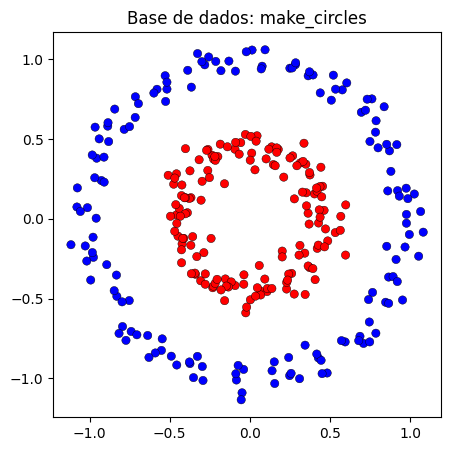

300 pontos, 150 da classe 0 (azul), 150 da classe 1 (vermelho)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

np.random.seed(42)

X, Y = make_circles(n_samples=300, noise=0.06, factor=0.45, random_state=42)

cores = ['blue' if k == 0 else 'red' for k in Y]
plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=cores, edgecolor='k', linewidth=0.3)
plt.title('Base de dados: make_circles')
plt.savefig('circulos.png', dpi=150)
plt.show()

print(f'{len(X)} pontos, {sum(Y==0)} da classe 0 (azul), {sum(Y==1)} da classe 1 (vermelho)')

## 2. Funções de ativação

- **Sigmoide**: $\sigma(v) = \dfrac{1}{1+e^{-v}}$, com derivada $\sigma'(v) = \sigma(v)(1-\sigma(v))$ — usada
  só na saída, porque comprime o resultado entre 0 e 1 (interpretável como probabilidade).
- **ReLU**: $\text{ReLU}(v) = \max(0, v)$, com derivada $1$ se $v>0$ e $0$ caso contrário — usada nas 3
  camadas escondidas, porque sua derivada não encolhe para entradas positivas, evitando o vanishing
  gradient numa rede mais profunda que a original.

In [3]:
def sigmoide(v):
    return 1 / (1 + np.exp(-v))

def sigmoide_deriv(v):
    s = sigmoide(v)
    return s * (1 - s)

def relu(v):
    return np.maximum(0, v)

def relu_deriv(v):
    return (v > 0).astype(float)

print('sigmoide(0) =', sigmoide(0), '  relu(-2) =', relu(-2), '  relu(3) =', relu(3))

sigmoide(0) = 0.5   relu(-2) = 0   relu(3) = 3


## 3. Arquitetura generalizada em matrizes

Para uma rede com $N$ camadas, definimos $\mathbf{a}^{(0)} = \mathbf{x}$ e, para cada camada
$l=1,\dots,N$:

$$\mathbf{v}^{(l)} = W^{(l)}\mathbf{a}^{(l-1)} + \mathbf{b}^{(l)} \qquad \mathbf{a}^{(l)} = \sigma^{(l)}(\mathbf{v}^{(l)})$$

Isso é o mesmo cálculo do `exemplo4.py` (que escrevia `s00 = w0[0,0]*x[0]`, `s01 = w0[0,1]*x[1]`,
`v0 = s00+s01+b0[0]` linha por linha para cada neurônio), só que a matriz $W^{(l)}$ faz todas essas
multiplicações e somas de uma vez, para qualquer número de neurônios.

Nossa arquitetura é $[2, 8, 6, 4, 1]$: 2 entradas, três camadas escondidas (8, 6, 4 neurônios), 1 saída.
Em código (com exemplos em linha, não em coluna), cada $W^{(l)}$ tem forma `(tamanhos[l], tamanhos[l+1])`.

In [4]:
def inicializar_pesos(tamanhos, seed=0):
    rng = np.random.RandomState(seed)
    L = len(tamanhos) - 1
    W = [rng.randn(tamanhos[i], tamanhos[i+1]) * 0.5 for i in range(L)]
    b = [np.zeros(tamanhos[i+1]) for i in range(L)]
    return W, b

tamanhos = [2, 8, 6, 4, 1]
W, b = inicializar_pesos(tamanhos, seed=0)
for i, (Wi, bi) in enumerate(zip(W, b)):
    print(f'camada {i+1}: W{i+1}.shape = {Wi.shape}   b{i+1}.shape = {bi.shape}')

camada 1: W1.shape = (2, 8)   b1.shape = (8,)
camada 2: W2.shape = (8, 6)   b2.shape = (6,)
camada 3: W3.shape = (6, 4)   b3.shape = (4,)
camada 4: W4.shape = (4, 1)   b4.shape = (1,)


## 4. Forward pass generalizado

Um laço `for` percorre as camadas — nenhuma é tratada como caso especial. As três primeiras usam ReLU,
a última usa sigmoide.

In [5]:
ativ = [relu, relu, relu, sigmoide]
ativ_deriv = [relu_deriv, relu_deriv, relu_deriv, sigmoide_deriv]

def forward(X, W, b):
    a = X
    cache_v, cache_a = [], [a]
    for l in range(len(W)):
        v = a @ W[l] + b[l]
        a = ativ[l](v)
        cache_v.append(v)
        cache_a.append(a)
    return a, cache_v, cache_a

yhat, cache_v, cache_a = forward(X, W, b)
print('formato da saida:', yhat.shape)
print('primeiras 5 predicoes (pesos ainda aleatorios):', yhat[:5].ravel())

formato da saida: (300, 1)
primeiras 5 predicoes (pesos ainda aleatorios): [0.49988611 0.50462743 0.5        0.5        0.50230456]


/var/folders/r8/drfpnd8s20zdvn7xfv0l7d7h0000gn/T/ipykernel_93417/2621087051.py:8: RuntimeWarning: divide by zero encountered in matmul
  v = a @ W[l] + b[l]
/var/folders/r8/drfpnd8s20zdvn7xfv0l7d7h0000gn/T/ipykernel_93417/2621087051.py:8: RuntimeWarning: overflow encountered in matmul
  v = a @ W[l] + b[l]
/var/folders/r8/drfpnd8s20zdvn7xfv0l7d7h0000gn/T/ipykernel_93417/2621087051.py:8: RuntimeWarning: invalid value encountered in matmul
  v = a @ W[l] + b[l]


Próximos passos
- Função de Perda
- Backward generalizado
- Treinamento (gradiente descendente em lote completo)
- Analisar resultados (curva de perda e fronteira de decisão)
- Validação cruzada com Keras
- Conclusão
